In [1]:
import pandas as pd

df = pd.read_csv('data/UK-HPI-full-file.csv')

print(df.head())
print(df.columns)
print(df.info())


# Remove duplicates
df = df.drop_duplicates()

# Check missing values
df.isnull().sum()

df = df.dropna()
df.isnull().sum()

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df = df.rename(columns={'AveragePrice': 'Price'})

         Date     RegionName   AreaCode  AveragePrice  Index  IndexSA  \
0  01/01/2004  Aberdeenshire  S12000034         84638   41.1      NaN   
1  01/02/2004  Aberdeenshire  S12000034         84623   41.1      NaN   
2  01/03/2004  Aberdeenshire  S12000034         86536   42.1      NaN   
3  01/04/2004  Aberdeenshire  S12000034         87373   42.5      NaN   
4  01/05/2004  Aberdeenshire  S12000034         89493   43.5      NaN   

   1m%Change  12m%Change  AveragePriceSA  SalesVolume  ...  NewPrice  \
0        NaN         NaN             NaN        388.0  ...  112843.0   
1        0.0         NaN             NaN        326.0  ...  113061.0   
2        2.3         NaN             NaN        453.0  ...  115218.0   
3        1.0         NaN             NaN        571.0  ...  115247.0   
4        2.4         NaN             NaN        502.0  ...  117377.0   

   NewIndex  New1m%Change  New12m%Change  NewSalesVolume  OldPrice  OldIndex  \
0      40.7           NaN            NaN        

<Axes: xlabel='Year'>

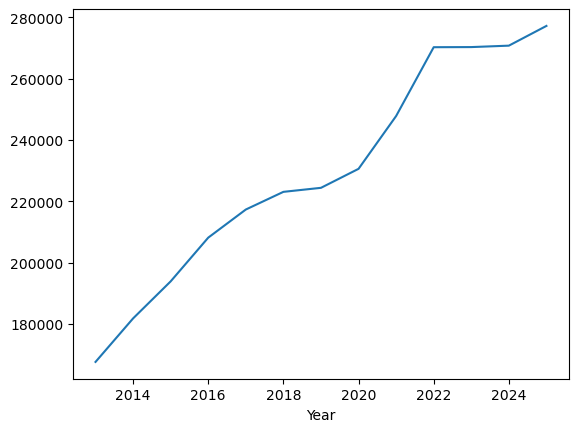

In [2]:
# EDA
#prices over time
df.groupby('Year')['Price'].mean().plot()

In [12]:
#prices by region
df.groupby('RegionName')['Price'].mean().sort_values().tail(10)


RegionName
Wales                   161545.493421
East Midlands           189247.861842
West Midlands Region    193274.756579
Great Britain           219613.467105
England and Wales       231704.901316
England                 236801.921053
South West              251767.756579
East of England         283396.710526
South East              324577.651316
London                  502081.059211
Name: Price, dtype: float64

In [4]:
#Discovered strong geographic influence on pricing, with South East regions showing consistently higher values.
#Lowest ≈ £161k
#Highest ≈ £502k
#Insight: There is a substantial regional price gap in the UK housing market, indicating uneven economic and housing demand distribution.

In [14]:
#MACHINE LEARNING PREDICTION
X = df[['Year', 'Month']]   # simple features
y = df['Price']

In [15]:
#TRAINING MODEL USING LINEAR REGRESSION
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
#PREDICTION
preds = model.predict(X_test)

In [17]:
#EVALUATION
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_test, preds))
import numpy as np

rmse = np.sqrt(7461682538.926516)
print(rmse)

# This model has limited predictive features

9118069284.295107
86381.03112909984


In [30]:
#TRAINING MODEL USING RANDOM FORESTS
df = df.sort_values('Date')

df['PrevPrice'] = df['Price'].shift(1)

df = df.dropna()

X = df[['Year', 'Month', 'PrevPrice']]
y = df['Price']



from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(rmse)

87334.4898528931


In [18]:
#Tried multiple models (Linear Regression, Random Forest) but performance remained similar due to limited feature availability,
#highlighting the importance of feature richness in predictive modeling

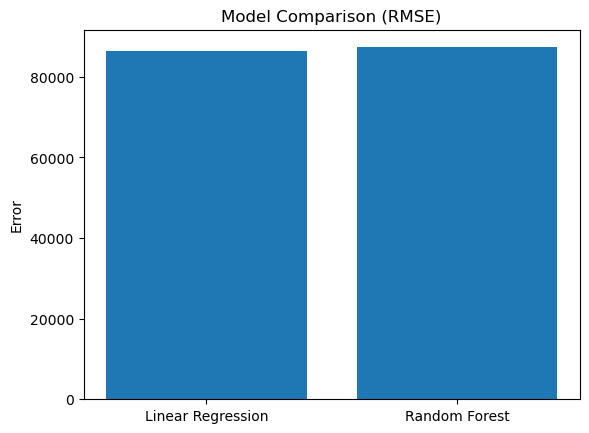

In [19]:
results = {
    "Linear Regression": 86381,
    "Random Forest": 87334
}

import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Comparison (RMSE)")
plt.ylabel("Error")
plt.show()

In [20]:
#UK Housing Price Analysis & Prediction
#Analyzed UK housing data to identify regional price disparities, 
#finding London prices nearly 3x higher than other regions. Built regression and ensemble models 
#for price prediction and evaluated performance, highlighting the impact of limited features on model accuracy.
#Tools: Python, Pandas, Scikit-learn, Matplotlib


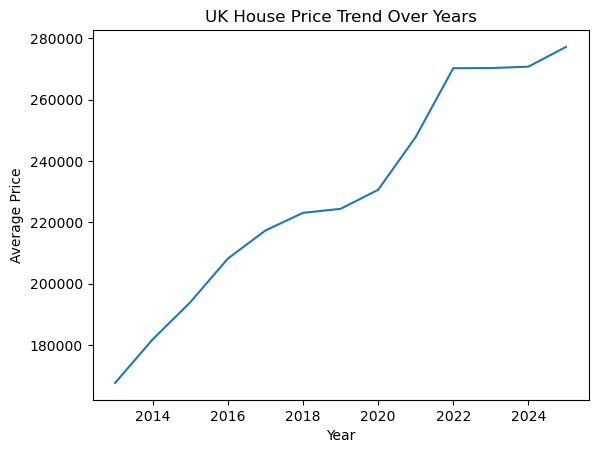

In [21]:
#Price Trend Over Time
import matplotlib.pyplot as plt

df.groupby('Year')['Price'].mean().plot()
plt.title("UK House Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

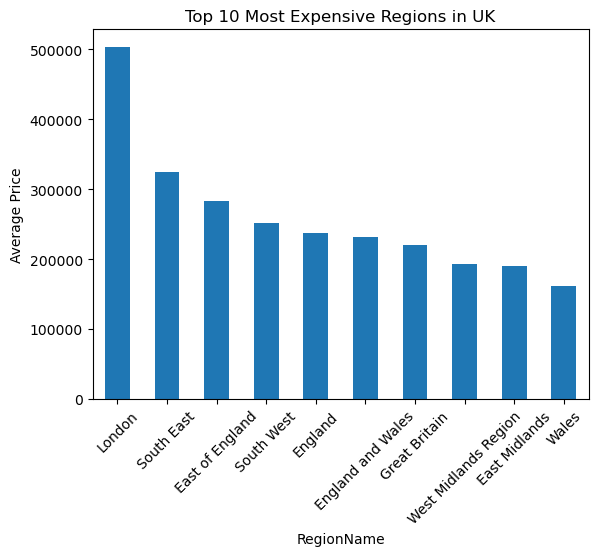

In [35]:
#Top 10 Expensive Regions
top_regions = df.groupby('RegionName')['Price'].mean().sort_values(ascending=False).head(10)

top_regions.plot(kind='bar')
plt.title("Top 10 Most Expensive Regions in UK")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.to_csv('cleaned_housing.csv', index=False)